In [1]:
from EXPERIMENT_HYPER_EMPIRICAL import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import matplotlib.colors as colors
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from scipy.sparse import diags, csc_matrix
import hypergraphx as hgx
from _HyperCommunityDetection import *
from hypergraphx.viz import draw_communities
from hypergraphx.viz.draw_hypergraph import draw_hypergraph
import warnings
import pandas
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

# high school

In [13]:
name = 'highschool'
ehg = EmpiricalHyperGraph(name)
# bulk
edge_order, edge_count = np.unique(ehg.H.sum(axis=0).flatten(), return_counts=True)
order_count = dict(zip(edge_order, edge_count))
print(order_count)
ds = dict()
for o in order_count:
    ds[o] = o * order_count[o] / ehg.n
bulk = 0
for k in ehg.Ks:
    bulk += ds[k] * (k - 1)
bulk = np.sqrt(bulk)
print(f'bulk radius is {bulk}')

Construct highschool hypergraph with 327 nodes, 7818 hyperedges and all possible k is [3, 4, 2, 5].
{2: 5498, 3: 2091, 4: 222, 5: 7}
bulk radius is 8.97601288654654


In [22]:
def scatter_spectral(eigvalue, fig=None, ax=None, title='Spectrum', title_x=0.25):
    # Construct scatter coordinate
    x = []
    y = []
    for _w in eigvalue:
        _x = _w.real if isinstance(_w, complex) else _w
        _y = _w.imag if isinstance(_w, complex) else 0
        x.append(_x)
        y.append(_y)
    if fig is None and ax is None:
        fig = plt.figure(figsize=(8, 8))
        widths = [4]
        heights = [4]
        spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
        row = 0
        col = 0
        ax = fig.add_subplot(spec5[row, col])
    ax.set_aspect('equal',adjustable='box')
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')
#     ax.xaxis.set_ticks_position('bottom')
    ax.spines['bottom'].set_position(('data', 0))
#     ax.yaxis.set_ticks_position('left')
    ax.spines['left'].set_position(('data', 0))
    ax.scatter(x, y, s=2)
    ax.set_title(title, x=title_x, y=1.07)

In [24]:
def plot_spectral_NBBH(sbm, bulk, extend_vline=2.65, eig_B=None, ylabel_coor1=(0.25,0.95), ylabel_coor2=(0.2,0.95), 
                       title_x=0.25, eigBH_amplify=1, xlabel_x=1.02):
#     print(f'SNR={sbm.get_SNR()}, d={d}')
    if eig_B is None:
        NB = sbm.get_operator('NB')
        print(np.shape(NB))
        eig_B, _ = eig(NB.toarray())
    info_eig = []
#     bulk = np.sqrt(d)
    for e in eig_B:
        if abs(e) > bulk and e.imag == 0:
            info_eig.append(e)
    print(info_eig)
    fig = plt.figure()
    widths = [5]
    heights = [5, 5]
    spec5 = fig.add_gridspec(ncols=1, nrows=2, width_ratios=widths, height_ratios=heights)
    row = 0
    col = 0
    ax = fig.add_subplot(spec5[row, col])
    scatter_spectral(eig_B, fig=fig, ax=ax, title=r"Spectrum of $\mathrm{NB}$", title_x=title_x)
    ax.add_patch(Circle(xy = (0.0, 0.0), radius=bulk, alpha=0.2))
    # ax.set_ylim(-bulk-1, 1 * bulk + 1)
    ax.set_xlim(min(info_eig).real-1, max(info_eig).real+1)
    left, right = ax.get_xlim()
    for e in info_eig:
        ax.axvline(e.real, c='black', ls=':', lw=1)
    ax.axvline(bulk, c='black', ls='-', lw=1)
    ax.set_xlabel('real', loc='right', size=15)
    ax.set_ylabel('imag', loc='top', size=15)
    ax.yaxis.set_label_coords(ylabel_coor1[0],ylabel_coor1[1])
    ax.xaxis.set_label_coords(xlabel_x, 0.4)
    y_locs, y_ticks = plt.yticks()
    x_locs, x_ticks = plt.xticks()
    ax.apply_aspect()
    
    row = 1
    col = 0
    ax = fig.add_subplot(spec5[row, col])
    bh_samples = 40
    c = gen_colors(start=colors_red[0], end=colors_green[0], n=bh_samples)
    i = 0
    eig_BHs = dict()
    eig_max = 0
    for r in np.linspace(bulk, max(info_eig).real+1, bh_samples):
        BH = sbm.get_operator('BH', r=r)
        eig_BH, _ = eig(BH.toarray())
        eig_BHs[r] = eig_BH
        eig_max = max(eig_BH) if max(eig_BH) > eig_max else eig_max
#     eig_max = max(eig_BHs[max(info_eig).real+1])
    for r in np.linspace(bulk, max(info_eig).real+1, bh_samples):
        eig_BH = eig_BHs[r]
        x = []
        y = []
        for _w in eig_BH:
            _y = _w.real if isinstance(_w, complex) else _w
            _y = _y / eig_max * (bulk + 1) * eigBH_amplify # normalize
            x.append(r)
            y.append(_y)
        ax.scatter(x, y, s=2, c=c[i])
        i += 1
    ax.set_aspect('equal',adjustable='box')
    ax.set_title(r"Spectrum of $\mathrm{BH_\lambda}$", x=title_x, y=1.07)
    ax.set_xlabel(r'$\lambda$', loc='right', size=15)
    ax.set_ylabel('eigenvalue', loc='top', size=15)
    ax.yaxis.set_label_coords(ylabel_coor2[0],ylabel_coor2[1])
    ax.xaxis.set_label_coords(1, 0.4)
    ax.set_yticks(y_locs, y_ticks)
    ax.set_xticks(x_locs, x_ticks)
    # ax.set_ylim(-bulk-1, 1 * bulk + 1)
#     ax.set_xlim(-bulk-1, max(info_eig).real+1)
    ax.set_xlim(left, right)
    for e in info_eig:
        ax.vlines(e.real, ymin=-bulk-1, ymax=bulk+extend_vline, colors='black', linestyles=':', linewidths=1, clip_on=False)
    ax.vlines(bulk, ymin=-bulk-1, ymax=bulk+extend_vline, colors='black', linestyles='-', linewidths=1, clip_on=False)
    ax.spines['left'].set_position(('data', 0.0))
    ax.spines['right'].set_color('none')
    ax.spines['bottom'].set_position(('data', 0.0))
    ax.spines['top'].set_color('none')
    ax.apply_aspect()

In [14]:
NB = ehg.get_operator('NB')
print(np.shape(NB))
eig_NB, eigv_NB = eig(NB.toarray())

Non-backtrack constructing for 18192 directed node-hyperEdge pairs...


330948864it [56:16, 98024.80it/s] 


(18192, 18192)


[(116.41592942149146+0j), (112.06934135760531+0j), (90.30677232830274+0j), (87.38853016832957+0j), (80.92446680479519+0j), (74.25957341013935+0j), (63.22408916461373+0j), (55.16026405434409+0j), (50.32953548907031+0j), (48.588498741213726+0j), (47.41044609798446+0j), (35.59920621969948+0j), (34.506270985148525+0j), (32.40859902203093+0j), (-28.72022679936499+0j), (29.421034786114298+0j), (-27.598278895883684+0j), (-26.555675092379264+0j), (-25.433881158536263+0j), (26.141063686900154+0j), (24.824360513910438+0j), (24.245419205490002+0j), (23.9806849911863+0j), (22.341584441165196+0j), (-21.18137355112842+0j), (21.796246100166243+0j), (-20.585124352204204+0j), (-20.376253831649414+0j), (-19.506475427282698+0j), (-19.400596514343967+0j), (-18.593720562357984+0j), (19.68156538089438+0j), (-18.162381498743134+0j), (19.085341551755356+0j), (-17.720806546233916+0j), (18.611945984014977+0j), (-17.19647457023061+0j), (18.068861681561362+0j), (-15.831751594054237+0j), (-15.684464547201413+0j), 

Construct $BH_117.41592942149146$: 100%|████████████████████████████████████████████████| 4/4 [00:00<00:00, 285.34it/s]


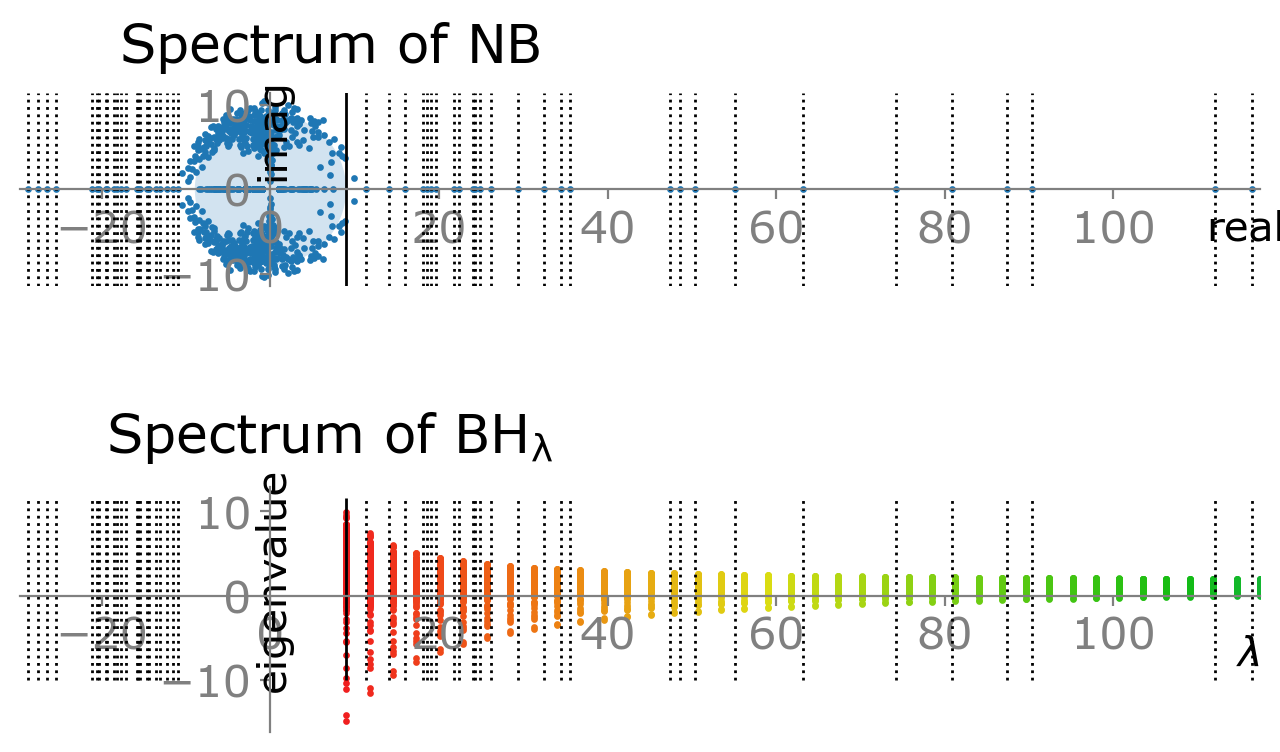

In [25]:
# assume_eig_B = np.array([bulk, 20])  # To fast check spectral of BH
plot_spectral_NBBH(ehg, bulk=bulk, eig_B=eig_NB, ylabel_coor1=(0.22, 1.08), ylabel_coor2=(0.22, 1.08), eigBH_amplify=1)

In [36]:
# Community Detection
givenNumGroup = 9
only_assortative = True
consider_ks = None
BH_Partition, BH_NumGroup = HyperCommunityDetect().BetheHessian(ehg, num_groups=givenNumGroup, 
                                                                only_assortative=only_assortative, 
                                                                consider_ks=consider_ks, 
                                                                givenBulk=50.32953548907031)

Construct $BH_50.32953548907031$: 100%|█████████████████████████████████████████████████| 4/4 [00:00<00:00, 249.92it/s]


In [30]:
def visualMetaCM(partition, meta):
    partition_num = np.size(np.unique(partition))
    meta_num = np.size(np.unique(meta))
#     cm, meta_index = get_confusionmatrix(partition, meta, partition_num, meta_num)
    cm = np.zeros((partition_num, meta_num))
    uniquePartition = np.unique(partition)
    uniqueMeta = np.unique(meta)
    for iP in uniquePartition:
        trueIndex = np.where(partition == iP)[0]
#         print(type(trueIndex))
        for iM in uniqueMeta:
            i = np.where(uniquePartition == iP)
            j = np.where(uniqueMeta == iM)
            cm[i, j] = np.size(np.where(meta[trueIndex]==iM))
#     print(confusionMatrix)
#     partition_ind, meta_ind = linear_sum_assignment(cm, maximize=True)
#     print(f'True index is {partition_ind}, Community detected index is {meta_ind}')
    df = pandas.DataFrame(cm, uniquePartition, uniqueMeta)
#     cm[:, np.sort(meta_ind)] = cm[:, meta_ind]
    return cm, df

In [37]:
# name = 'highschool'
# givenNumGroup = 13
# only_assortative = True
# consider_ks = None
# partition_path = f'./result/hyperEmpirical/{name}_BHPartition' \
#             f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
#             f'{f"_assort" if only_assortative else ""}' \
#             f'{f"{consider_ks}" if consider_ks is not None else ""}.pkl'
# partition = None
# with open(partition_path, 'rb') as fr:
#     partition = pickle.load(fr)
meta = []
with open('./net_data/contact-high-school/highschool_data.pkl', 'rb') as fr:
    _data = pickle.load(fr)
    for i in range(_data['n']):
        meta.append(_data['meta'][i])
meta = np.array(meta)
cm, df = visualMetaCM(BH_Partition, meta)
print(f'number of partition {np.size(np.unique(BH_Partition))}, number of meta {np.size(np.unique(meta))}')
path = f'./result/hyperEmpirical/{name}_cm' \
        f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
        f'{f"_assort" if only_assortative else ""}_test10.23.xlsx'

with pandas.ExcelWriter(path) as writer:
    df.to_excel(excel_writer=writer)
    writer._save()

number of partition 9, number of meta 9


In [27]:
partition_names = ["2BIO1", '2BIO2', '2BIO3','MP', 'MP*1', 'MP*2','PSI*', 'PC', 'PC*']
meta = []
with open('./net_data/contact-high-school/highschool_data.pkl', 'rb') as fr:
    _data = pickle.load(fr)
    for i in range(_data['n']):
        meta.append(_data['meta'][i])
meta = np.array(meta)
metaIndex = [partition_names.index(m) for m in meta]
metaI, metaC = np.unique(metaIndex, return_counts=True)
reorder_index = np.argsort(metaIndex)

Construct $BH_11.326$: 100%|████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 266.40it/s]


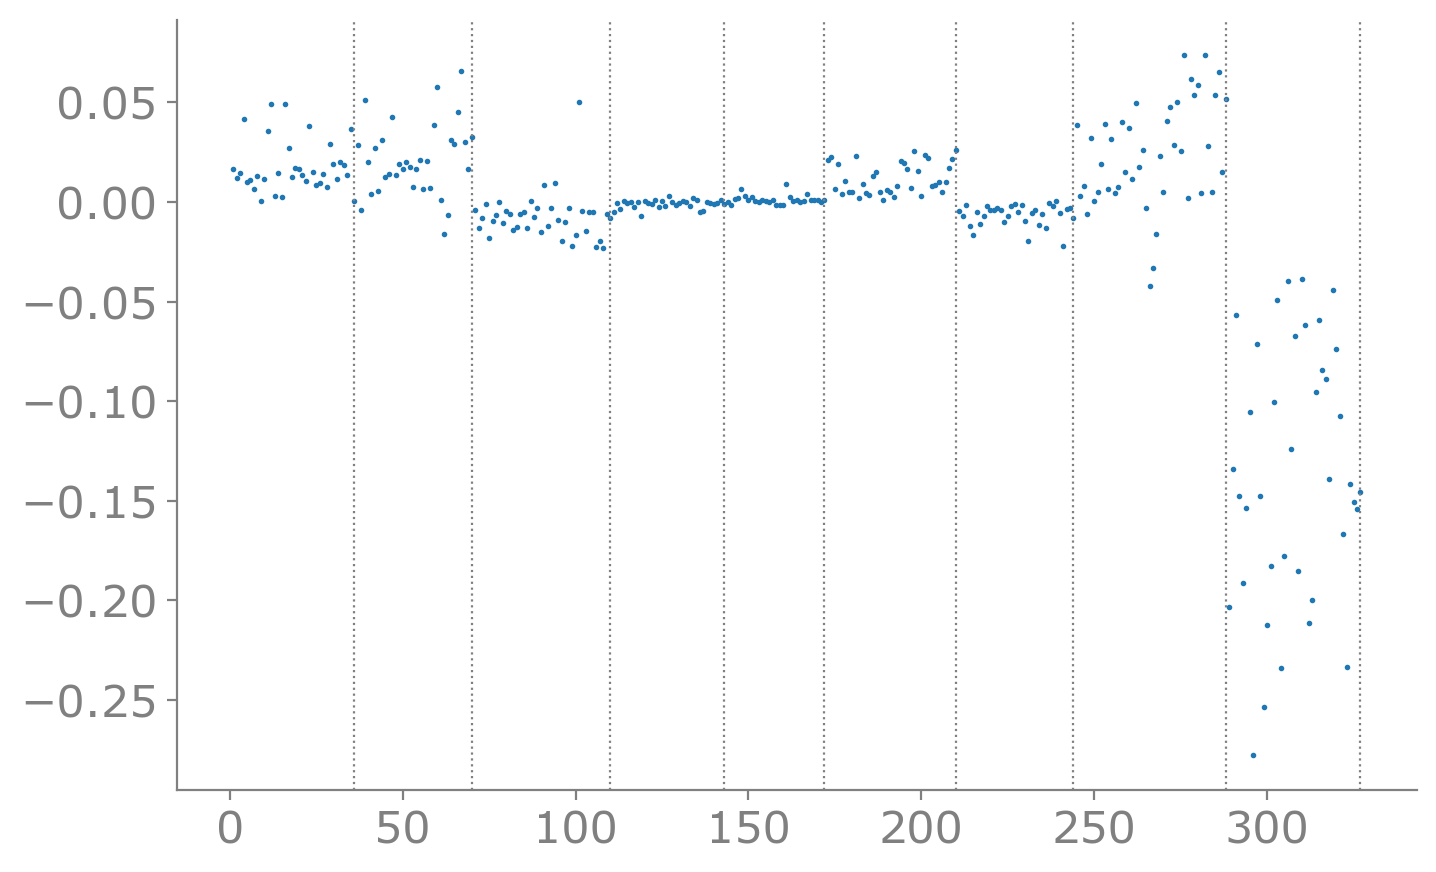

In [28]:
bulk_by_observe = 11.326
BH = ehg.get_operator('BH', r=bulk_by_observe)
eig_val, eig_vecs = eig(BH.toarray())
# print(f'{np.size(eig_vec)}')
eig_index = 4
eig_vec = eig_vecs[:, eig_index][reorder_index]
plt.scatter(np.linspace(1, ehg.n, ehg.n), eig_vec, s=1)
for i in range(9):
    cummulation_count = np.sum(metaC[:i+1])
    plt.axvline(cummulation_count, color='gray', lw=0.8, ls=':')

# Enron

In [7]:
name = 'enron'
ehg = EmpiricalHyperGraph(name)
# bulk
edge_order, edge_count = np.unique(ehg.H.sum(axis=0).flatten(), return_counts=True)
order_count = dict(zip(edge_order, edge_count))
print(order_count)
ds = dict()
for o in order_count:
    ds[o] = o * order_count[o] / ehg.n
bulk = 0
for k in ehg.Ks:
    bulk += ds[k] * (k - 1)
bulk = np.sqrt(bulk)
print(f'bulk radius is {bulk}')

Construct enron hypergraph with 150 nodes, 1725 hyperedges and all possible k is [2, 3, 4].
{2: 1070, 3: 535, 4: 120}
bulk radius is 6.728050733062784


In [10]:
NB = ehg.get_operator('NB')
print(np.shape(NB))
eig_NB, eigv_NB = eig(NB.toarray())

Non-backtrack constructing for 4225 directed node-hyperEdge pairs...


17850625it [03:01, 98380.18it/s] 


(4225, 4225)


[(81.42869725799346+0j), (69.87384022348057+0j), (41.64690763904511+0j), (38.68625055714379+0j), (34.433769149124565+0j), (28.796408550359427+0j), (26.186807165431187+0j), (-22.719173367507167+0j), (21.512431237850485+0j), (18.370392556620416+0j), (16.6662740677119+0j), (-16.838082300043993+0j), (-16.16052890075504+0j), (14.696512047850302+0j), (13.245154064315766+0j), (-13.788047910108105+0j), (-12.881938179993174+0j), (-12.62503280114845+0j), (8.57143658956148+0j), (-10.062946569076075+0j), (7.381469001805936+0j), (-8.10277605289657+0j)]


D:\BackProgram\Anaconda\envs\network\Lib\site-packages\matplotlib_inline\config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):
Construct $BH_82.42869725799346$: 100%|█████████████████████████████████████████████████| 3/3 [00:00<00:00, 299.84it/s]
D:\BackProgram\Anaconda\envs\network\Lib\site-packages\matplotlib\collections.py:192: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


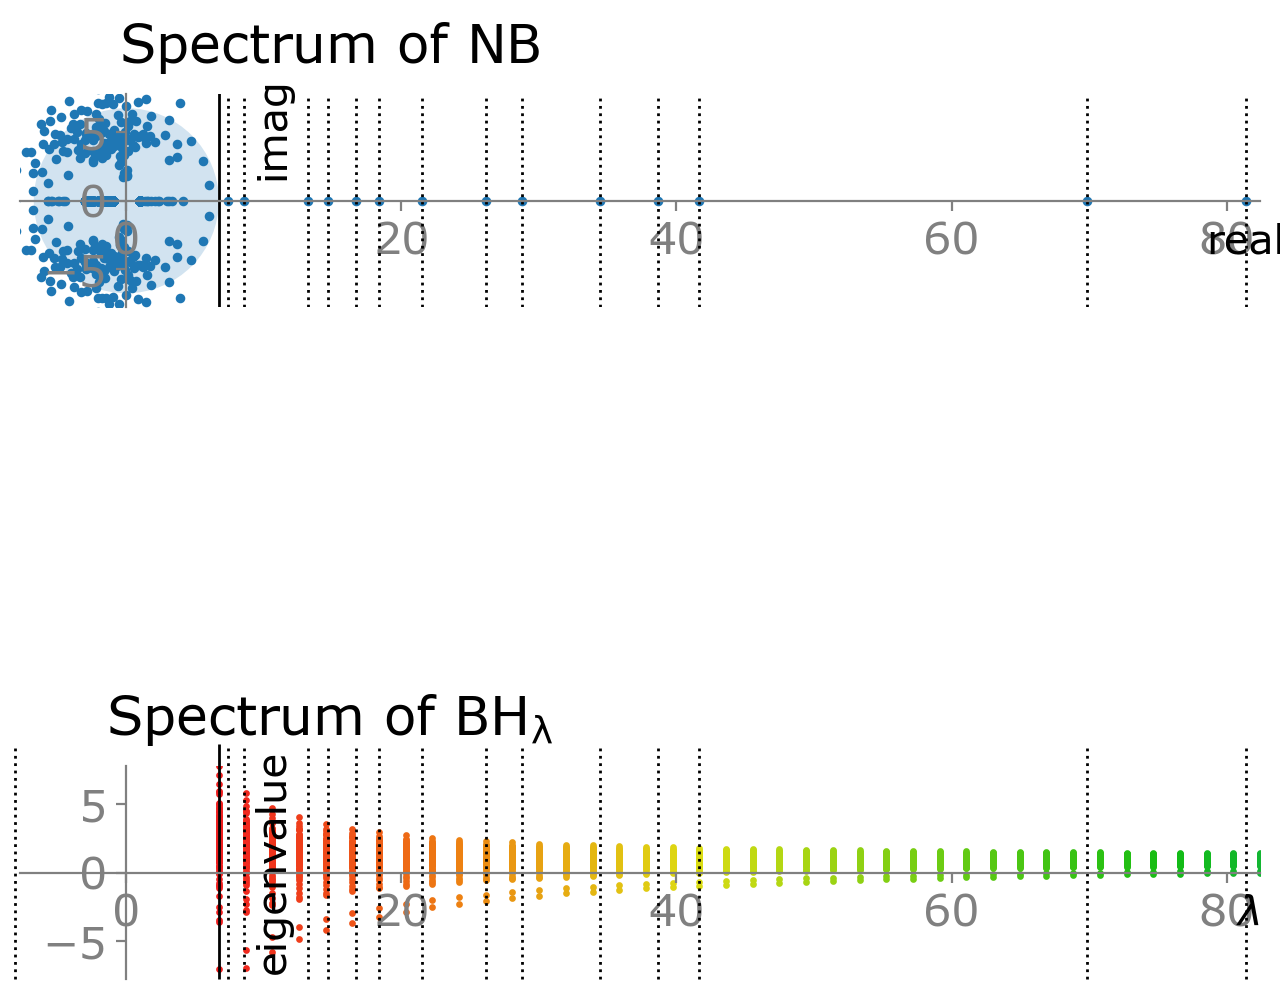

In [12]:
plot_spectral_NBBH(ehg, bulk=bulk, eig_B=eig_NB, ylabel_coor1=(0.22, 1.08), ylabel_coor2=(0.22, 1.08), eigBH_amplify=1)